<a href="https://colab.research.google.com/github/SamuelMcAdoo/lecturestuff/blob/main/Assignment3GANImages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generating Images using GAN.
The learning problem I will undertake in this Jupyter Notebook is generating images using Generative Adversarial Networks. Compared to what we have studied in class, which is mostly classification and text generation, generating images presents a more tricky problem, because images are expected to be overall cohesive, instead of a text generator for example which mostly only reuqires cohesiveness on a word-to-word basis: From this perspective, an image generator is like asking a Neural Network to generate an entire paragraph.


In [2]:
# Imports..:
import tensorflow as tf
# We'll be using Keras, which has our dataset already included, which is handy.
from tensorflow import keras
from tensorflow.keras import layers
# As always..:
import matplotlib.pyplot as plt
import numpy as np

# Dataset
The Dataset chosen for this project is the Fashion MNIST dataset, publicly available at https://www.kaggle.com/datasets/zalando-research/fashionmnist. We have used MNIST datasets before in this class, and of particular note in this instance is that the MNIST datasets are callable from within the Keras library, where they appear pre-formatted for our purposes.

Though pre-formatted, they still require some small amounts of coaxing to get them into the final format for the ingestastion of the Neural Network to come.

In [3]:
# Load in the Fashion MNIST dataset from Keras..:
(x_train, y_train), (_, _) = keras.datasets.fashion_mnist.load_data()
# Normalize to -1 ... 1 ..:
x_train = x_train.astype("float32") / 255.0
x_train = (x_train - 0.5) * 2.0
# Adding a channel dim..:
x_train = np.expand_dims(x_train, axis=-1)

# Final Dataset setup..:
buffer_size = x_train.shape[0]
batch_size = 128

dataset = (
    tf.data.Dataset.from_tensor_slices(x_train)
    .shuffle(buffer_size)
    .batch(batch_size,drop_remainder=True)
)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


We can see some of the Fashion MNIST example images here below. As in some of our labs, these are 28x28 black-and-white images.

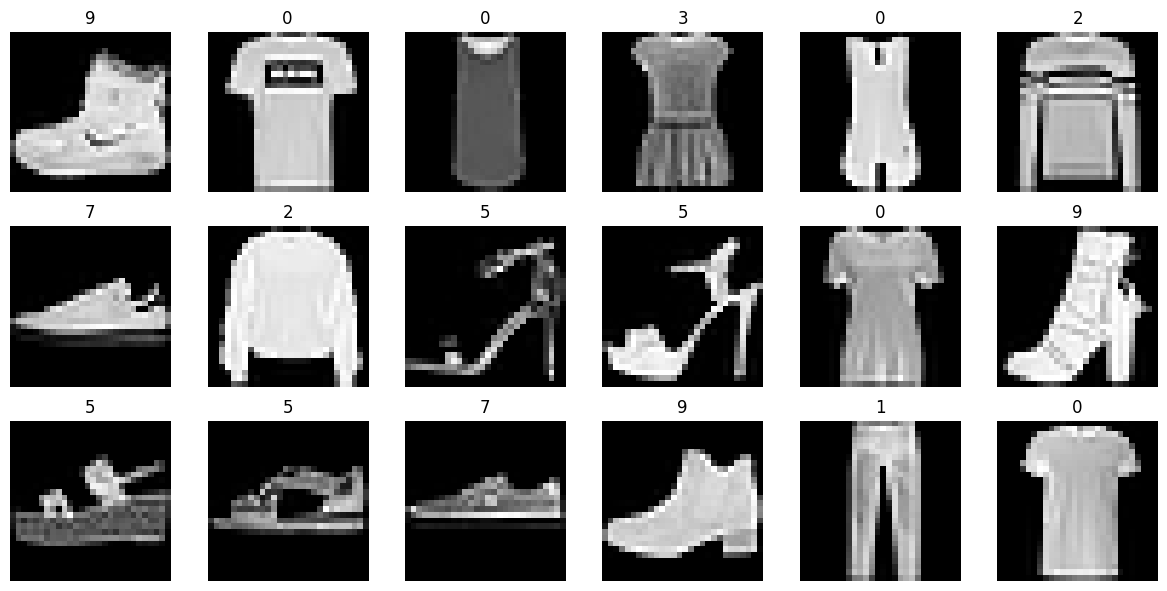

In [4]:
def show_samples(images, labels=None, num_rows=3, num_cols=5):
    plt.figure(figsize=(num_cols * 2, num_rows * 2))

    for i in range(num_rows * num_cols):
        plt.subplot(num_rows, num_cols, i + 1)

        img = images[i]
        if img.ndim == 3:
            img = img.squeeze()

        plt.imshow(img, cmap="gray")
        plt.axis("off")

        if labels is not None:
            plt.title(str(labels[i]))

    plt.tight_layout()
    plt.show()

show_samples(x_train, y_train, num_rows=3, num_cols=6)

# Neural Network Architecture
The Generative Adversarial Network works essentially by using one network to train the other network.

 We create a generator network, which takes a random sampling noise and is expected to refine it into an image which resembles the Fashion MNIST images. This is the "Generator".

 The Generator's outputs are then fed into an adversary, the "Discriminator". The purpose of this network is to discern whether or not a given image, in the 28x28 format, is likely to be within the Fashion MNIST dataset.

 The goal, then, of the combined architecture, is to refine the Generator using the Discriminator's outputs such that, for the Discriminator, the Generator's outputs are indistinguishable from the base Dataset.

The Generator's Architecture is found below. It takes in a 28x28 canvas of noise, and runs ReLU on an increasing number of neurons until we eventually have slightly more neurons than pixels. It then compresses those into -1...1 and is done, ready to send its' creations to the discerner.

In [5]:
z_dim = 100

def build_generator(z_dim=100):
    model = keras.Sequential(name="generator")
    model.add(layers.Input(shape=(z_dim,)))
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(1024))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(28 * 28 * 1, activation="tanh"))
    model.add(layers.Reshape((28, 28, 1)))
    return model

generator = build_generator(z_dim)
generator.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │       803,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,486,352 (5.67 MB)

 Trainable params: 1,486,352 (5.67 MB)

 Non-trainable params: 0 (0.00 B)

Largely, we can see that the Discriminator works basically as the inverse of the Generator. It takes an image of 784 pixels, and filters it down to a simple probability of whether or not an image is likely to be within the MNIST dataset bounded from 0 .. 1.



In [6]:
def build_discriminator():
    model = keras.Sequential(name="discriminator")
    model.add(layers.Input(shape=(28, 28, 1)))
    model.add(layers.Flatten())
    model.add(layers.Dense(512))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(256))
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dense(1, activation="sigmoid"))  # probability of real
    return model

discriminator = build_discriminator()
discriminator.summary()


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

# Loss Functions

The Loss Functions for GAN are where things are pretty interesting, and are the "meat and potatoes" of what I talked about above.

Cross Entropy is used, as we would expect, to parse the loss for a binary decision (in this case real vs. fake image).

In [7]:
# Training parameters
lr = 2e-4
num_epochs = 100

cross_entropy = keras.losses.BinaryCrossentropy(from_logits=False)

# Optimizer..:
generator_optimizer = keras.optimizers.Adam(learning_rate=lr, beta_1=0.5, beta_2=0.999)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=lr, beta_1=0.5, beta_2=0.999)

# Monitoring stuff ..:
num_examples_to_generate = 16
seed = tf.random.normal([num_examples_to_generate, z_dim])


For the Discriminator, in each batch we give it some fake and some real images. It wants to correctly discriminate which is which. Thus, the 'desired' output is a "1" (real) for any real_output, and a "0" (fake) for any fake_output.

The loss f'n here is set up to be minimized closest to the above scenario, which is the ideal for GAN.

In [8]:
def discriminator_loss(real_output, fake_output):
    # Real -> 1
    # Fake -> 0
    real_labels = tf.ones_like(real_output)
    fake_labels = tf.zeros_like(fake_output)
    real_loss = cross_entropy(real_labels, real_output)
    fake_loss = cross_entropy(fake_labels, fake_output)
    total_loss = real_loss + fake_loss
    return total_loss


For the Generator, we care about the return we get *from* the discriminator. An output given by the discriminator closest to "1" (real) is always desirable.

The loss f'n here is minimized when the Discriminator returns a value as close as possible to "1".

In [9]:
def generator_loss(fake_output):
    real_labels = tf.ones_like(fake_output)
    return cross_entropy(real_labels, fake_output)

# Training

Training the Generative Adversarial Network is relatively simple. First, we make a ton of random noise, and then ask the Generator function to refine. The Generator function's goal is to generate an image that can "slip past" the discriminator with a good detection score, and the Discriminator wants to prevent that. They compete, and in so doing, train eachother. Really, it's like having two networks playing a game with eachother.

In [10]:
@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]

    # Sample noise
    noise = tf.random.normal([batch_size, z_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        # Generate fake images
        generated_images = generator(noise, training=True)

        # Discriminator outputs
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Compute losses
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)

    # Compute and apply gradients
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


Some demonstrative functions.

In [11]:
# You can ignore this. It has little to do with GAN. It just handles some
#   demonstrative/illustrative image generation, so we can see what's going on.
def generate_and_show_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    predictions = (predictions + 1.0) / 2.0

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i, :, :, 0], cmap="gray")
        plt.axis("off")

    plt.suptitle(f"Epoch {epoch}")
    plt.show()


The Training phase for the network is just applying the Training function across a bunch of Epochs, many more than the networks we used in class. From my testing, the network needs at least 25 or 30 epochs before the results are any good, but around 100 is an ideal medium between time and output quality.

Epoch 1/100 - Gen loss: 1.1167, Disc loss: 0.7629


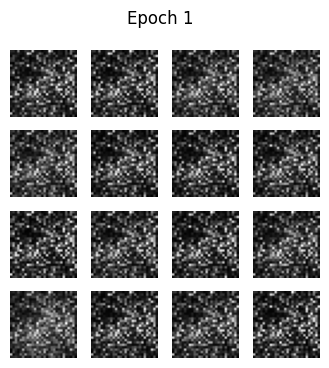

Epoch 2/100 - Gen loss: 1.4709, Disc loss: 0.6983
Epoch 3/100 - Gen loss: 1.7519, Disc loss: 0.5509
Epoch 4/100 - Gen loss: 1.6556, Disc loss: 0.6396
Epoch 5/100 - Gen loss: 1.5430, Disc loss: 0.7186
Epoch 6/100 - Gen loss: 1.5475, Disc loss: 0.7525


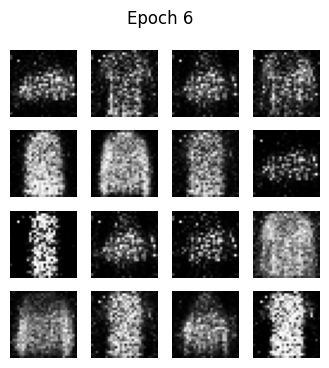

Epoch 7/100 - Gen loss: 1.2486, Disc loss: 0.9392
Epoch 8/100 - Gen loss: 1.2264, Disc loss: 0.9726
Epoch 9/100 - Gen loss: 1.1220, Disc loss: 1.0561
Epoch 10/100 - Gen loss: 1.0321, Disc loss: 1.1227
Epoch 11/100 - Gen loss: 1.0043, Disc loss: 1.1385


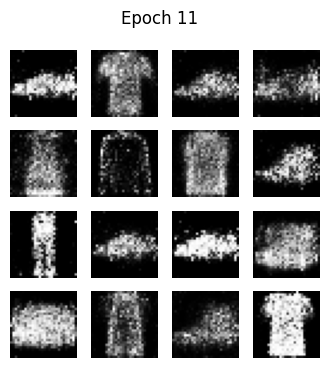

Epoch 12/100 - Gen loss: 0.9840, Disc loss: 1.1531
Epoch 13/100 - Gen loss: 0.9757, Disc loss: 1.1616
Epoch 14/100 - Gen loss: 0.9516, Disc loss: 1.1835
Epoch 15/100 - Gen loss: 0.9332, Disc loss: 1.2049
Epoch 16/100 - Gen loss: 0.9259, Disc loss: 1.2131


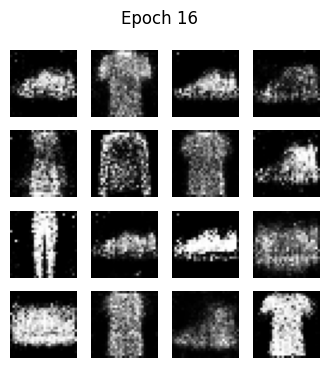

Epoch 17/100 - Gen loss: 0.9141, Disc loss: 1.2213
Epoch 18/100 - Gen loss: 0.9200, Disc loss: 1.2165
Epoch 19/100 - Gen loss: 0.9068, Disc loss: 1.2279
Epoch 20/100 - Gen loss: 0.8902, Disc loss: 1.2461
Epoch 21/100 - Gen loss: 0.8781, Disc loss: 1.2598


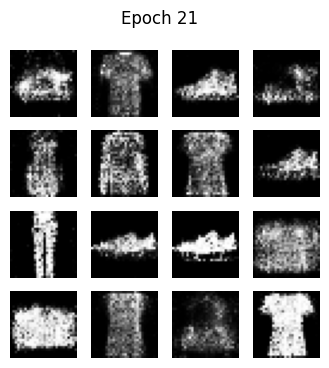

Epoch 22/100 - Gen loss: 0.8683, Disc loss: 1.2714
Epoch 23/100 - Gen loss: 0.8556, Disc loss: 1.2776
Epoch 24/100 - Gen loss: 0.8558, Disc loss: 1.2786
Epoch 25/100 - Gen loss: 0.8554, Disc loss: 1.2809
Epoch 26/100 - Gen loss: 0.8414, Disc loss: 1.2888


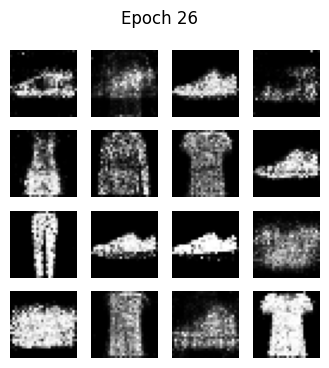

Epoch 27/100 - Gen loss: 0.8357, Disc loss: 1.2950
Epoch 28/100 - Gen loss: 0.8351, Disc loss: 1.2963
Epoch 29/100 - Gen loss: 0.8351, Disc loss: 1.2938
Epoch 30/100 - Gen loss: 0.8411, Disc loss: 1.2928
Epoch 31/100 - Gen loss: 0.8380, Disc loss: 1.2907


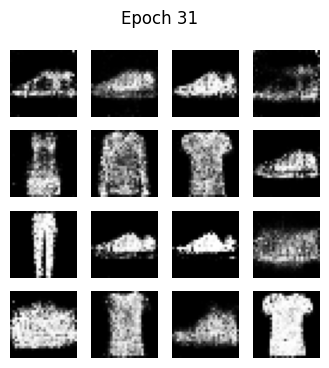

Epoch 32/100 - Gen loss: 0.8248, Disc loss: 1.3007
Epoch 33/100 - Gen loss: 0.8314, Disc loss: 1.2962
Epoch 34/100 - Gen loss: 0.8312, Disc loss: 1.2956
Epoch 35/100 - Gen loss: 0.8319, Disc loss: 1.2968
Epoch 36/100 - Gen loss: 0.8266, Disc loss: 1.2987


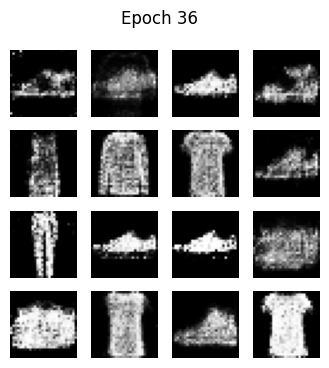

Epoch 37/100 - Gen loss: 0.8151, Disc loss: 1.3066
Epoch 38/100 - Gen loss: 0.8170, Disc loss: 1.3076
Epoch 39/100 - Gen loss: 0.8172, Disc loss: 1.3064
Epoch 40/100 - Gen loss: 0.8224, Disc loss: 1.3026
Epoch 41/100 - Gen loss: 0.8138, Disc loss: 1.3078


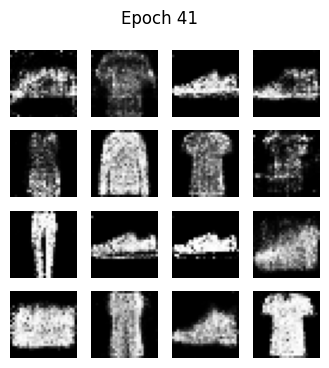

Epoch 42/100 - Gen loss: 0.8159, Disc loss: 1.3073
Epoch 43/100 - Gen loss: 0.8142, Disc loss: 1.3071
Epoch 44/100 - Gen loss: 0.8102, Disc loss: 1.3098
Epoch 45/100 - Gen loss: 0.8131, Disc loss: 1.3099
Epoch 46/100 - Gen loss: 0.8117, Disc loss: 1.3099


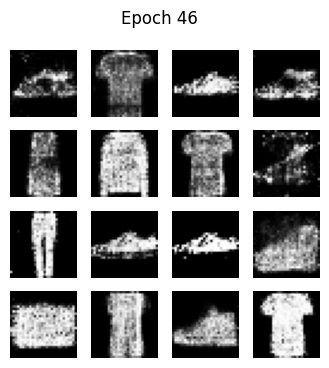

Epoch 47/100 - Gen loss: 0.8062, Disc loss: 1.3129
Epoch 48/100 - Gen loss: 0.8093, Disc loss: 1.3090
Epoch 49/100 - Gen loss: 0.8132, Disc loss: 1.3075
Epoch 50/100 - Gen loss: 0.8105, Disc loss: 1.3091
Epoch 51/100 - Gen loss: 0.8127, Disc loss: 1.3067


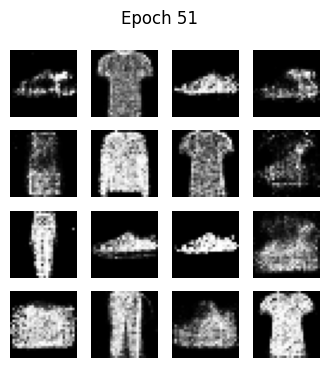

Epoch 52/100 - Gen loss: 0.8134, Disc loss: 1.3054
Epoch 53/100 - Gen loss: 0.8103, Disc loss: 1.3064
Epoch 54/100 - Gen loss: 0.8157, Disc loss: 1.3040
Epoch 55/100 - Gen loss: 0.8049, Disc loss: 1.3117
Epoch 56/100 - Gen loss: 0.8144, Disc loss: 1.3043


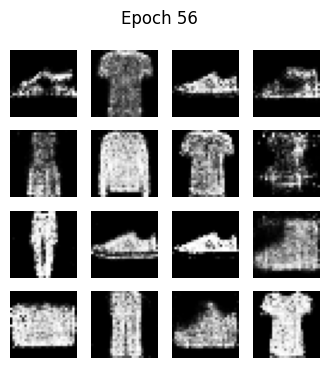

Epoch 57/100 - Gen loss: 0.8128, Disc loss: 1.3036
Epoch 58/100 - Gen loss: 0.8113, Disc loss: 1.3085
Epoch 59/100 - Gen loss: 0.8100, Disc loss: 1.3073
Epoch 60/100 - Gen loss: 0.8060, Disc loss: 1.3122
Epoch 61/100 - Gen loss: 0.8107, Disc loss: 1.3067


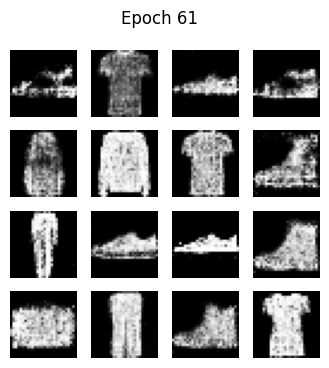

Epoch 62/100 - Gen loss: 0.8111, Disc loss: 1.3066
Epoch 63/100 - Gen loss: 0.8147, Disc loss: 1.3041
Epoch 64/100 - Gen loss: 0.8083, Disc loss: 1.3086
Epoch 65/100 - Gen loss: 0.8105, Disc loss: 1.3081
Epoch 66/100 - Gen loss: 0.8053, Disc loss: 1.3087


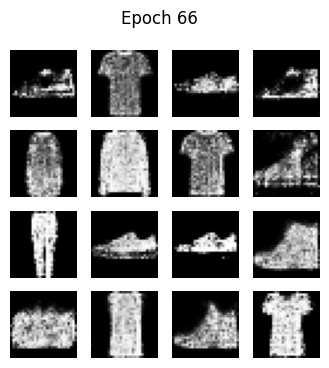

Epoch 67/100 - Gen loss: 0.8098, Disc loss: 1.3088
Epoch 68/100 - Gen loss: 0.8085, Disc loss: 1.3075
Epoch 69/100 - Gen loss: 0.8118, Disc loss: 1.3065
Epoch 70/100 - Gen loss: 0.8083, Disc loss: 1.3093
Epoch 71/100 - Gen loss: 0.8084, Disc loss: 1.3086


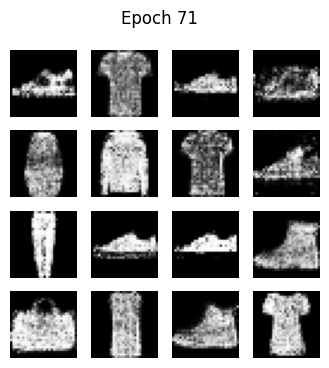

Epoch 72/100 - Gen loss: 0.8055, Disc loss: 1.3086
Epoch 73/100 - Gen loss: 0.8074, Disc loss: 1.3077
Epoch 74/100 - Gen loss: 0.7999, Disc loss: 1.3140
Epoch 75/100 - Gen loss: 0.8076, Disc loss: 1.3077
Epoch 76/100 - Gen loss: 0.8086, Disc loss: 1.3083


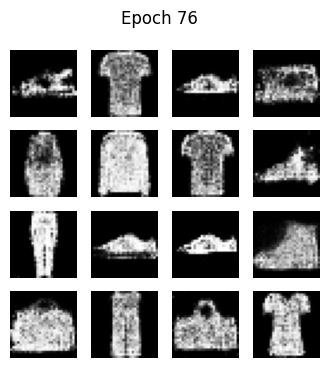

Epoch 77/100 - Gen loss: 0.8038, Disc loss: 1.3120
Epoch 78/100 - Gen loss: 0.8042, Disc loss: 1.3110
Epoch 79/100 - Gen loss: 0.7999, Disc loss: 1.3139
Epoch 80/100 - Gen loss: 0.8130, Disc loss: 1.3027
Epoch 81/100 - Gen loss: 0.8083, Disc loss: 1.3064


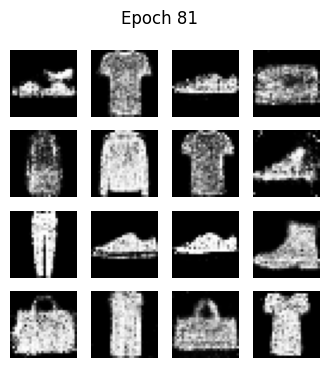

Epoch 82/100 - Gen loss: 0.8023, Disc loss: 1.3139
Epoch 83/100 - Gen loss: 0.8024, Disc loss: 1.3112
Epoch 84/100 - Gen loss: 0.8062, Disc loss: 1.3087
Epoch 85/100 - Gen loss: 0.8036, Disc loss: 1.3111
Epoch 86/100 - Gen loss: 0.8093, Disc loss: 1.3081


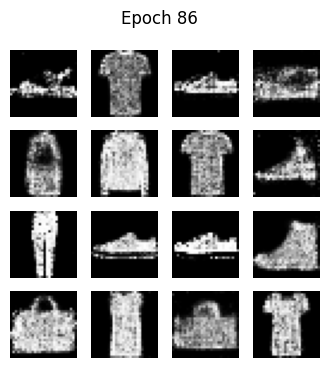

Epoch 87/100 - Gen loss: 0.8094, Disc loss: 1.3054
Epoch 88/100 - Gen loss: 0.8052, Disc loss: 1.3079
Epoch 89/100 - Gen loss: 0.8053, Disc loss: 1.3090
Epoch 90/100 - Gen loss: 0.8052, Disc loss: 1.3115
Epoch 91/100 - Gen loss: 0.8081, Disc loss: 1.3061


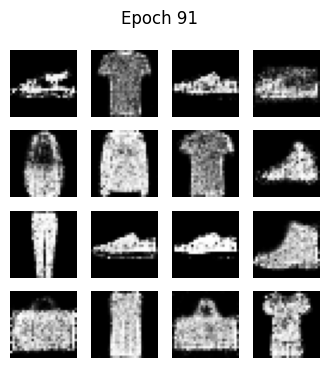

Epoch 92/100 - Gen loss: 0.8098, Disc loss: 1.3039
Epoch 93/100 - Gen loss: 0.8059, Disc loss: 1.3066
Epoch 94/100 - Gen loss: 0.8058, Disc loss: 1.3080
Epoch 95/100 - Gen loss: 0.8095, Disc loss: 1.3044
Epoch 96/100 - Gen loss: 0.8132, Disc loss: 1.3024


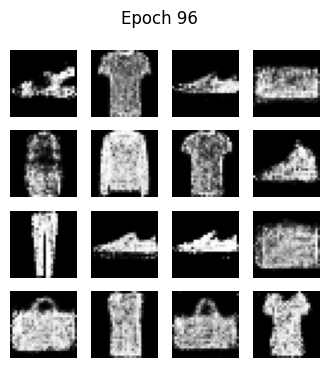

Epoch 97/100 - Gen loss: 0.8141, Disc loss: 1.3009
Epoch 98/100 - Gen loss: 0.8106, Disc loss: 1.3055
Epoch 99/100 - Gen loss: 0.8023, Disc loss: 1.3114
Epoch 100/100 - Gen loss: 0.8090, Disc loss: 1.3038


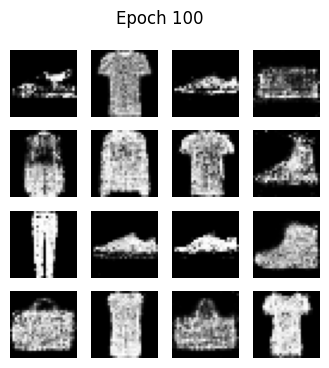

In [12]:
def train(dataset, epochs):
    for epoch in range(1, epochs + 1):
        gen_losses = []
        disc_losses = []

        for batch in dataset:
            gen_loss, disc_loss = train_step(batch)
            gen_losses.append(gen_loss)
            disc_losses.append(disc_loss)


        # Unimportant Logging stuff for demonstrative purposes..:
        print(
            f"Epoch {epoch}/{epochs} "
            f"- Gen loss: {tf.reduce_mean(gen_losses):.4f}, "
            f"Disc loss: {tf.reduce_mean(disc_losses):.4f}"
        )


        if epoch % 5 == 1 or epoch == epochs:
            generate_and_show_images(generator, epoch, seed)

# Train the model. This takes a while.
train(dataset, num_epochs)


After all is said and done, we can ask the Generator to produce an image, and it will do pretty well!

You'll notice that the Discriminator is not used for this. Your own eye is the discriminator, now!

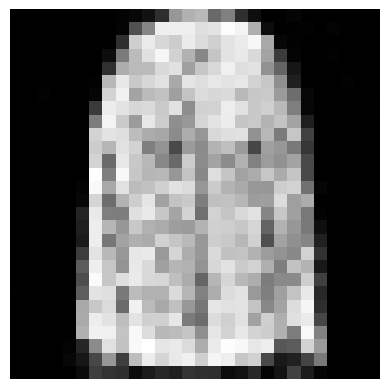

In [36]:
def generate_single_image(generator, z_dim=100):
    noise = tf.random.normal([1, z_dim])

    generated = generator(noise, training=False)

    generated = (generated + 1.0) / 2.0

    img = generated[0, :, :, 0].numpy()

    plt.imshow(img, cmap="gray")
    plt.axis("off")
    plt.show()

generate_single_image(generator)